This notebook builds SVM classifiers to predict fuel type.

Dataset description: The dataset contains information on vehicles(cars). it includes records of: model, make, year of model, class of vehicle, no. of cylinders, engine size, *fuel type*, transimission, fuel consumption (in the city, on the highway, or combined), and CO2 emissions.
This dataset was used prior to predict fuel consumption but it will be used for predicting fuel type.

Setup Stage.

In [12]:
#import of necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC # Support Vector Classification with kernels
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

Data exploration, preparation, and preprocessing.

In [3]:
df = pd.read_csv('FuelConsumption.csv') # load the dataset
df.head() # return the first 5 rows to briefly check if all is well

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
df.info() # glean more insights/info about the data
# 1067 actual entries, there are 1068 rows in the dataset so I assume the rows with the labels are counted as null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [5]:
# Select columns with object datatype
object_columns = df.select_dtypes(include=['object']).columns.tolist()

# Display the list of columns with object datatype to get a cleaner look at what to drop
print(object_columns)

['MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE']


Explanation of the code below:

The appropriate input features to keep are Enginsize, CO2 emissions, and the fuel consumption inputs.

The year the car was made is irrelevant in what I am trying to predict and serves as noise thus it is dropped, this same logic applies for Make, Transmission, and VehicleClass (partly redundant as it is obvious that bigger cars have a larger engine size, also I am working with numerical data not categorical text so this won't be encoded as it is not needed) .

Model (in relation to car model) has too high cardinality (unique values) and would cause performance issues if I used one-hot encoding as I would have a lot of 1s and 0s and run the risk of overfitting the machine learning model as it would memorise car model strings of numbers as opposed to learning an underlying relationship within the data. Ordinal encoding cannot be used as there is no rank in the Model data.

Drop fueltype as that is our target/y value/dependent variable I want to predict.

In [6]:
target_col = "FUELTYPE" # the target to predict

# Featrue selection
X = df.drop(columns=['MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'MODELYEAR', target_col]) # pandas built in drop function, cleaing data

df.isnull().sum() # Sanity check to see if there is any missing or corrupted data

MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

Encoding Categorical Target.

To prevent errors of plugging in a categorical target yet using numerical values to predict it I preprocess the data further by using label encoding and converting the FUELTYPE values into a number.

In [7]:
le = LabelEncoder() # initialise le with the built in LabelEncoder() function from scikit-learn. LabelEncoder as I am converting the target variable and not the features, hence not OrdinalEncoder.
y = le.fit_transform(df[target_col]) # prepocess the target_col, calculate the required parameters with fit() and use the transform() method to apply the calculated parameters for data standardisation.
#Label encoder transforms the nominal categorical data into a numerical mformat that the ML model will understand


Scaling.

Data scaling is important as it ensures that there are no wild outliers that could skew data. It transforms the values of the features of a dataset so they are within a set range and so that no feature dominates the distance calculations in the algorithms.

Since I am using the StandardScaler() method instead of mormalisation (the values of each feature being between 0 and 1) it means that the mean of each feature becomes 0 and the standard deviation becomes 1.

In rgeards to SVM, the features must be scaled since SVM creates a hyperplane with margins between support vectors. This means if the features were not scaled/shrunk down to the same range then the feature(s) with large range(s) have a bigger influence on the distance calculation than other features, this means that: the distance calculations will be off, some features will be overly dominant on the distance calculation in relation to the less dominant/smaller ranged features, and ineffective separation. SVM also uses Euclidean distance wihich is sensitive to the scale of variables (same logic that applies to large ranged features dominatinf distance between two point computations applies to this too).



In [8]:
# Scale the numerical features, target was not numerical and has been encoded so it does not need to be scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Data splitting

In [9]:
# Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y) # standard split size, random_state is used to ensure reproducability
# stratify=y is used to split the FUELTYPE types proportianlly across both datasets so for instance Z is not overrepresented in the train and test sets, the same split of FUELTYPE values will remain even after the data is split into train and test

Building and training SVM models.

Mapping data into a higher space is called kernelling. SVM uses different kind of kernels, kernels also transform the feature space.

F1 Score is a ML evaluation metric that measures model precision and recall to then measure the model's acccuracy. Since my dataset is class balanced it is a reliable metric as each class of the dataset is balanced, meaning each class(category that will be output) of the dataset has the same number of samples(rows). Why balanced dataset matters is because if 90% of my FUELTYPE data is Z and the model predicts Z all the time even though it will have high accuracy it will not be a good model as it does not account for minority cases.

To calculate F1 score firstly the components (precision and recall) must be claculated.
Precision = True Positives (TP/Correct Predictions) divided by All Positive  Predictions (TP+FP)  TP/(TP+FP)
Recall = Correct Positive Predictions (TP) divided by All Positive Instances (TP+FN)

Precision measures how often you are correct
Recall measures all actual positives that were correctly identified as positives


The functions used for mapping are called kernels

SVM Kernel Types explained:

Linear Kernels are the simplest from of kernels used in SVM. It is viable when a straight line can effectivel separate the classes. Represented as K(x,y)=x.y.

Radial Basis Function (RBF) Kernel is used in non-linear instances where no prior knowledge about the data structure is available, it maps the data into an inifnite-dimensional space and is highly effective for complex classification problems. Most widely used SVM Kernel.

Polyniomial Kernel allos SVM to model complex relationships by using polynomial terms. It is good when the data is not linearly separable (line separating the dat points) but still follos a pattern. Represented as K(x,y)=(x.y+c)^d, where a constant and d is the polynomial degree (x^d in ponlynomial reg)

Sigmoid Kernel is inspired by Neural Networks (NNs) and behaves like the activation of a neuron. It is often used in NNs and non-linear classifiers. Also based on the hyperbolic tangent function. 
 


In [10]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid'] # denifed a list of types of kernels I will use, these are some common types but not all types as Gaussian kernels are ommitted

for k in kernels:
    model = SVC(kernel=k, class_weight='balanced', gamma='scale') # create an SVM classifier using the kernel in the current position of the loop, balance the dataset and give equal weight to all samples based on its class according to its class proportion
    model.fit(X_train, y_train) # train the model on the training data
    y_pred = model.predict(X_test) # predict the fuel type based off of the teat features/X independent variables
    f1 = f1_score(y_test, y_pred, average='macro') # measure F1 score, macro average calculates the precision and recall scores as arithmetic mean of each indicual classes' P and R scores. Calc F1 score per class then take the mean/basic average. Calculate the F1 scores of y test and y pred, see if y pred is accurately predicting (i.e. has a high f1 score)
    print(f"\nKernel: {k}")
    print(f"F1 Score (macro): {f1:.3f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_)) #use target_names=le.classes_ to display original class names


Kernel: linear
F1 Score (macro): 0.848
              precision    recall  f1-score   support

           D       1.00      1.00      1.00         5
           E       1.00      1.00      1.00        19
           X       0.72      0.74      0.73       103
           Z       0.68      0.66      0.67        87

    accuracy                           0.73       214
   macro avg       0.85      0.85      0.85       214
weighted avg       0.73      0.73      0.73       214


Kernel: rbf
F1 Score (macro): 0.834
              precision    recall  f1-score   support

           D       1.00      1.00      1.00         5
           E       1.00      1.00      1.00        19
           X       0.68      0.79      0.73       103
           Z       0.69      0.55      0.61        87

    accuracy                           0.71       214
   macro avg       0.84      0.83      0.83       214
weighted avg       0.72      0.71      0.71       214


Kernel: poly
F1 Score (macro): 0.712
              p

Visualisation of the results.

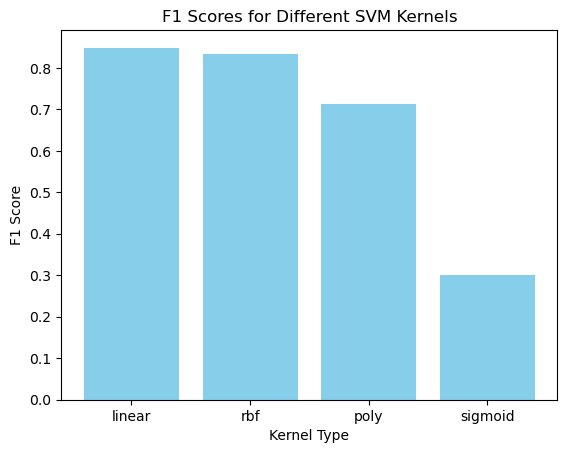

In [11]:
# Store results in empty list
f1_results = []

for k in kernels:
    model = SVC(kernel=k, class_weight='balanced', gamma='scale')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    f1_results.append(f1) # append the f1 score for the current kernel type in the loop/the current iteration/position in the list

plt.bar(kernels, f1_results, color='skyblue')
plt.title('F1 Scores for Different SVM Kernels')
plt.xlabel('Kernel Type')
plt.ylabel('F1 Score')
plt.show()

Conclusion.

Since the Linear Kernel has the hifghest F1 Score (best precision and recall) on the predicted fueltypes and test fueltypes it performs the best. The other kernels that are more suited for non-linearity (polynomial, and sigmoid) performed the worst, meaning the data can be separated by a line and this kernel requires the least amount of computational power/overhead.

Perhaps I could have used cross-validation and pipelines. I could have also used a confusion matrix to see what exact predictions were correct.

References:

https://metana.io/blog/support-vector-machine-svm-classifier-in-python-svm-classifier-python-code/
https://github.com/cliffordnwanna/ELECTRIC_VEHICLE_TYPE_PREDICTION/blob/main/NOTEBOOK/Electric%20Vehicle%20Type%20Prediction.ipynb
https://datascience.stackexchange.com/questions/39317/difference-between-ordinalencoder-and-labelencoder
https://how.dev/answers/what-is-the-use-of-fittransform-from-sklearn-in-python
https://www.geeksforgeeks.org/machine-learning/ml-label-encoding-of-datasets-in-python/
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html

https://medium.com/codex/why-scaling-your-data-is-important-1aff95ca97a2
https://stats.stackexchange.com/questions/279911/why-is-svm-sensitive-to-scaling-of-features
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
https://scikit-learn.org/stable/modules/svm.html
https://www.geeksforgeeks.org/machine-learning/major-kernel-functions-in-support-vector-machine-svm/
https://medium.com/@abhishekjainindore24/svm-kernels-and-its-type-dfc3d5f2dcd8

https://www.geeksforgeeks.org/machine-learning/how-does-the-classweight-parameter-in-scikit-learn-work/
https://datascience.stackexchange.com/questions/56250/how-does-class-weight-work-in-decision-tree

https://www.geeksforgeeks.org/machine-learning/fit-method-in-pythons-scikit-lear/

https://www.v7labs.com/blog/f1-score-guide

https://sklearn-evaluation.ploomber.io/en/latest/classification/micro_macro.html

https://www.evidentlyai.com/classification-metrics/accuracy-precision-recall
https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall